# Transform Black and White TIFF to Matplotlib's Default Color Scheme

This notebook reads a black and white TIFF image and saves a copy with matplotlib's default color scheme (viridis) while preserving the original resolution.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
# Path to the original TIFF file
input_path = "OT data 80 um/Copies for the paper/C10.tif"

# Path for saving the output file
output_path = "OT data 80 um/Copies for the paper/C10_colored.png"

In [3]:
# Read the TIFF image
img = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)

# Display original image information
print(f"Image shape: {img.shape}")
print(f"Image data type: {img.dtype}")
print(f"Min value: {np.min(img)}")
print(f"Max value: {np.max(img)}")

Image shape: (2000, 2000)
Image data type: uint16
Min value: 0
Max value: 65535


In [4]:
# Normalize the image data to the range [0, 1] for matplotlib colormapping
if img.dtype != np.uint8:
    # For higher bit depth images, normalize based on actual range
    img_normalized = (img - np.min(img)) / (np.max(img) - np.min(img))
else:
    # For 8-bit images
    img_normalized = img / 255.0

# Apply viridis colormap (matplotlib's default)
colored_img = cm.viridis(img_normalized)

# Convert to uint8 for saving (0-255 range, RGBA format)
colored_img_uint8 = (colored_img * 255).astype(np.uint8)

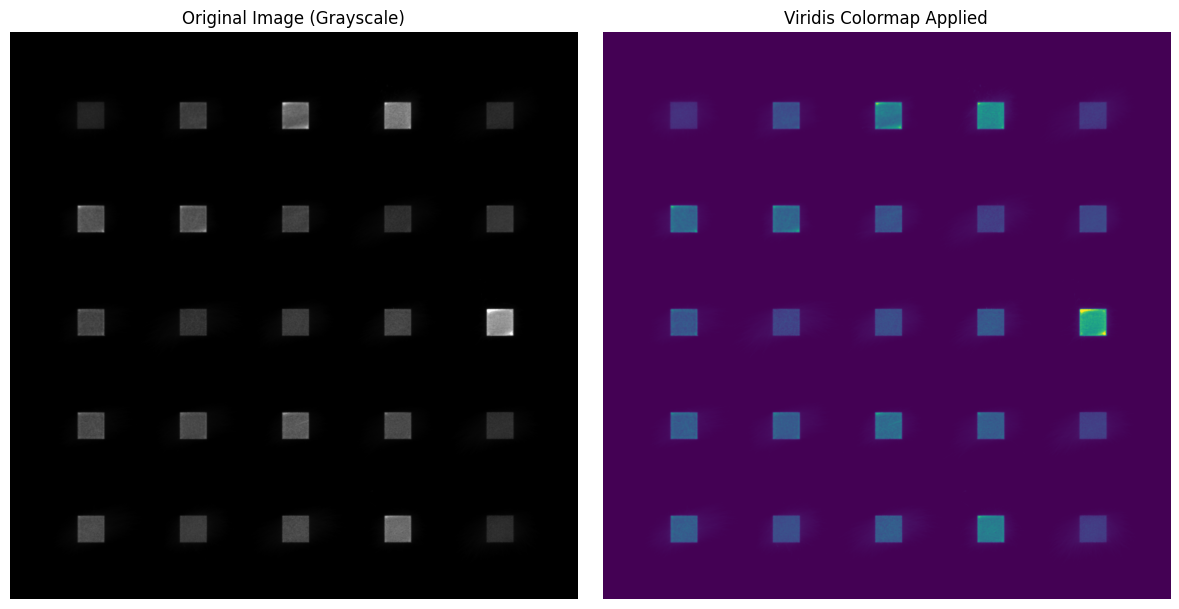

In [5]:
# Display original and colored images side by side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(colored_img)
plt.title('Viridis Colormap Applied')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Save the colored image
# OpenCV expects BGR order for colored images, but we have RGBA, so we'll use plt.imsave
plt.imsave(output_path, colored_img)
print(f"Colored image saved to {output_path}")

KeyError: 'TIF'

In [ ]:
# Verify that the saved image can be loaded correctly
# Note: When reading the saved image, use plt.imread to preserve the colors correctly
saved_img = plt.imread(output_path)
plt.figure(figsize=(8, 8))
plt.imshow(saved_img)
plt.title('Saved Colored Image')
plt.axis('off')
plt.show()